In [ ]:
print("ayoub")

ayoub


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator

d:\computer_vision_env\Computer_Vision_project\cifar100-project\src\data\loader.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='bytes')


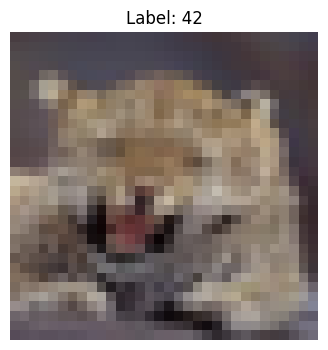

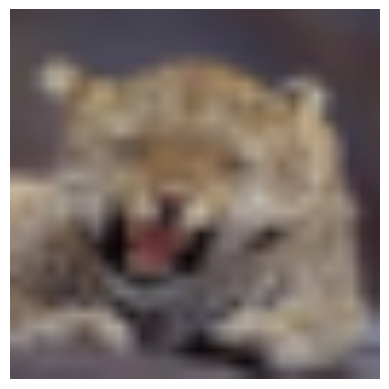

Path: d:\computer_vision_env\CV_dataset\train\train
Exists: True
(50000, 32, 32, 3)
0.0 1.0
Test Path: d:\computer_vision_env\CV_dataset\test\test
Exists: True
Test shape: (10000, 32, 32, 3)
Test min/max: 0.0 1.0


In [3]:
import sys
import os

# Ajouter le chemin parent du dossier 'src'
sys.path.append(os.path.abspath('..'))


from src.data.loader import load_data
from src.data.preprocess import normalize, reshape_images

# Chemin corrigé
file_path = os.path.abspath("../../../../CV_dataset/train/train")

# Vérification (IMPORTANT)
print("Path:", file_path)
print("Exists:", os.path.exists(file_path))
# charger
train_data = load_data(file_path)


X_train = train_data[b'data']
y_train = train_data[b'fine_labels']



# preprocessing
X_train = reshape_images(X_train)
X_train = normalize(X_train)

print(X_train.shape)
print(X_train.min(), X_train.max())

test_path = os.path.abspath("../../../../CV_dataset/test/test")

print("Test Path:", test_path)
print("Exists:", os.path.exists(test_path))

test_data = load_data(test_path)

X_test = test_data[b'data']
y_test = test_data[b'fine_labels']

# preprocessing (IMPORTANT : même traitement que train)
X_test = reshape_images(X_test)
X_test = normalize(X_test)

print("Test shape:", X_test.shape)
print("Test min/max:", X_test.min(), X_test.max())

In [11]:
meta_path = os.path.abspath("../../../../CV_dataset/meta")

meta_data = load_data(meta_path)

fine_label_names = meta_data[b'fine_label_names']

# convertir en string lisible
fine_label_names = [name.decode('utf-8') for name in fine_label_names]

In [10]:

y_train = np.array(y_train)
y_test = np.array(y_test)

y_train.shape

(50000,)

In [12]:
fine_label_names[y_train[50]]

'shark'

In [13]:
len(np.unique(y_train))

100

In [ ]:


# Data augmentation (optionnel)
datagen = ImageDataGenerator(
    rotation_range=0,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
datagen.fit(X_train)

# ----------------------------
# 2. Charger DenseNet121 pré-entraîné (ImageNet)
#    et adapter aux images 32x32
# ----------------------------
# DenseNet121 de Keras attend par défaut des images 224x224.
# On peut soit redimensionner nos 32x32 à 224x224 (simple mais coûteux),
# soit modifier l'entrée en gardant 32x32.
# Pour éviter le redimensionnement, on utilise 'include_top=False' et on ajoute nos couches.

base_model = DenseNet121(
    include_top=False,          # enlève le classifieur fully connected
    weights='imagenet',
    input_shape=(32, 32, 3)    # on force la taille 32x32 (Keras va adapter automatiquement)
)

# Important : La première convolution de DenseNet121 a un noyau 7x7, stride 2,
# ce qui réduit fortement la dimension spatiale. Pour du 32x32, c'est problématique.
# Solution simple : redimensionner les images en entrée à 224x224 (plus fiable).
# Je te conseille plutôt cette approche (redimensionnement) car elle est robuste.
# Voici comment faire avec redimensionnement :

# Option recommandée : redimensionner les images
def preprocess_image(x):
    x = tf.image.resize(x, (224, 224))
    return tf.keras.applications.densenet.preprocess_input(x)

# Appliquer le redimensionnement dans le DataGenerator ou en prétraitement
x_train_resized = tf.image.resize(X_train, (224, 224))
x_test_resized = tf.image.resize(X_test, (224, 224))
x_train_resized = tf.keras.applications.densenet.preprocess_input(x_train_resized)
x_test_resized = tf.keras.applications.densenet.preprocess_input(x_test_resized)

# Maintenant on peut utiliser DenseNet121 normalement
base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# ----------------------------
# 3. Fine-tuning en deux étapes
# ----------------------------
# Étape A : Geler le corps du modèle, ajouter une nouvelle tête
base_model.trainable = False   # geler toutes les couches pré-entraînées

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])

# Compiler avec un taux d'apprentissage élevé pour la nouvelle tête
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 1 : Entraînement de la tête seulement...")
model.fit(x_train_resized, y_train,
          batch_size=64,
          epochs=5,
          validation_data=(x_test_resized, y_test),
          verbose=1)

# Étape B : Fine-tuning complet (dégeler + petit lr)
base_model.trainable = True
# On peut choisir de geler les premières couches (optionnel)
# Par exemple, on gèle les 100 premières couches (à ajuster)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompiler avec un très petit taux d'apprentissage
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 2 : Fine-tuning complet...")
model.fit(x_train_resized, y_train,
          batch_size=64,
          epochs=10,
          validation_data=(x_test_resized, y_test),
          verbose=1)